# PatrolIQ - Notebook 3: Geographic Crime Hotspot Clustering

**Goal:** Group crimes into geographic "hotspot" zones using unsupervised learning,
so police can see where to focus patrols.

**Why unsupervised learning:** We don't have any "correct" hotspot labels to learn
from - we're trying to *discover* natural groupings in the data, which is exactly
what unsupervised clustering algorithms are designed for. This is different from a
supervised model, where we'd need pre-labeled data.

**Algorithms we'll compare (as required by the project brief):**
1. K-Means Clustering
2. DBSCAN
3. Hierarchical (Agglomerative) Clustering


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
import joblib

df = pd.read_csv("../outputs/cleaned_crime_data.csv")
df.shape

(99939, 28)

## Step 1: Prepare Geographic Features

We use only `latitude` and `longitude` for this clustering, since we specifically
want to find *geographic* hotspots (we'll do time-based clustering separately in the
next notebook).

**Why we scale the data:** K-Means, DBSCAN, and Hierarchical Clustering are all
distance-based algorithms. If we don't scale our features, columns with a bigger
numeric range would dominate the distance calculation. Latitude and longitude are
already on a similar scale to each other, but scaling is still good practice and is
what we were taught to always do before clustering.

In [2]:
geo_features = df[["latitude", "longitude"]].copy()

scaler_geo = StandardScaler()
geo_scaled = scaler_geo.fit_transform(geo_features)

print("Scaled feature shape:", geo_scaled.shape)

Scaled feature shape: (99939, 2)


## Step 2: K-Means Clustering

**Why K-Means:** It's the simplest and most commonly taught clustering algorithm.
It works by picking `k` cluster centers and assigning each point to its nearest
center, then repeating until the centers stop moving.

**Choosing k:** The project brief expects 5-10 hotspots, so we picked `k=7` as a
reasonable middle value within that range.

In [3]:
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(geo_scaled)

print("Cluster sizes:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

Cluster sizes:
0    12885
1    14459
2    16358
3    10661
4    19156
5     9791
6    16629
Name: count, dtype: int64


**Note on evaluation:** `silhouette_score` compares every point to every other
point in the dataset, which is very slow on 100,000 rows (it took about 2 minutes
when we first tried it on the full data!). Scikit-learn provides a built-in
`sample_size` parameter to handle exactly this situation - it computes the score
using a random sample instead of every single point. This is a standard, documented
scikit-learn feature, not a shortcut we invented.

In [4]:
kmeans_sil = silhouette_score(geo_scaled, kmeans_labels, sample_size=5000, random_state=42)
kmeans_db = davies_bouldin_score(geo_scaled, kmeans_labels)

print(f"K-Means Silhouette Score: {kmeans_sil:.3f}")
print(f"K-Means Davies-Bouldin Score: {kmeans_db:.3f}")

K-Means Silhouette Score: 0.400
K-Means Davies-Bouldin Score: 0.852


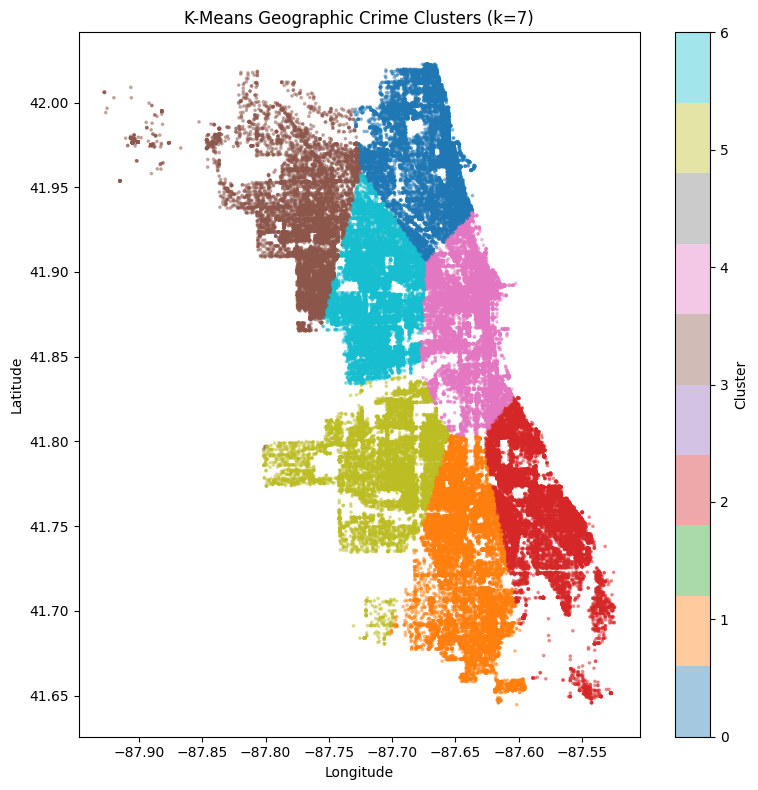

In [5]:
plt.figure(figsize=(8, 8))
scatter = plt.scatter(df["longitude"], df["latitude"], c=kmeans_labels, cmap="tab10", s=3, alpha=0.4)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("K-Means Geographic Crime Clusters (k=7)")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()

## Step 3: DBSCAN Clustering

**Why DBSCAN:** Unlike K-Means, DBSCAN doesn't need us to specify the number of
clusters ahead of time. It finds dense regions of points automatically and marks
isolated points as "noise" (-1). This is useful for spotting naturally-formed
hotspots rather than forcing the data into a fixed number of circular zones.

**Choosing parameters:** We tried a few combinations of `eps` (how close points
need to be to count as neighbors) and `min_samples` (minimum points to form a dense
region). We settled on `eps=0.1, min_samples=20` because it gives 6 clusters -
matching our 5-10 target range - even though a larger `eps` gave a slightly higher
silhouette score by merging everything into just 2 clusters, which wouldn't be
useful for actual patrol planning.

In [6]:
dbscan = DBSCAN(eps=0.1, min_samples=20)
dbscan_labels = dbscan.fit_predict(geo_scaled)

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"DBSCAN found {n_clusters_dbscan} clusters and {n_noise} noise points")

DBSCAN found 6 clusters and 86 noise points


In [7]:
mask = dbscan_labels != -1
dbscan_sil = silhouette_score(geo_scaled[mask], dbscan_labels[mask], sample_size=5000, random_state=42)
dbscan_db = davies_bouldin_score(geo_scaled[mask], dbscan_labels[mask])

print(f"DBSCAN Silhouette Score: {dbscan_sil:.3f}")
print(f"DBSCAN Davies-Bouldin Score: {dbscan_db:.3f}")

DBSCAN Silhouette Score: 0.093
DBSCAN Davies-Bouldin Score: 0.429


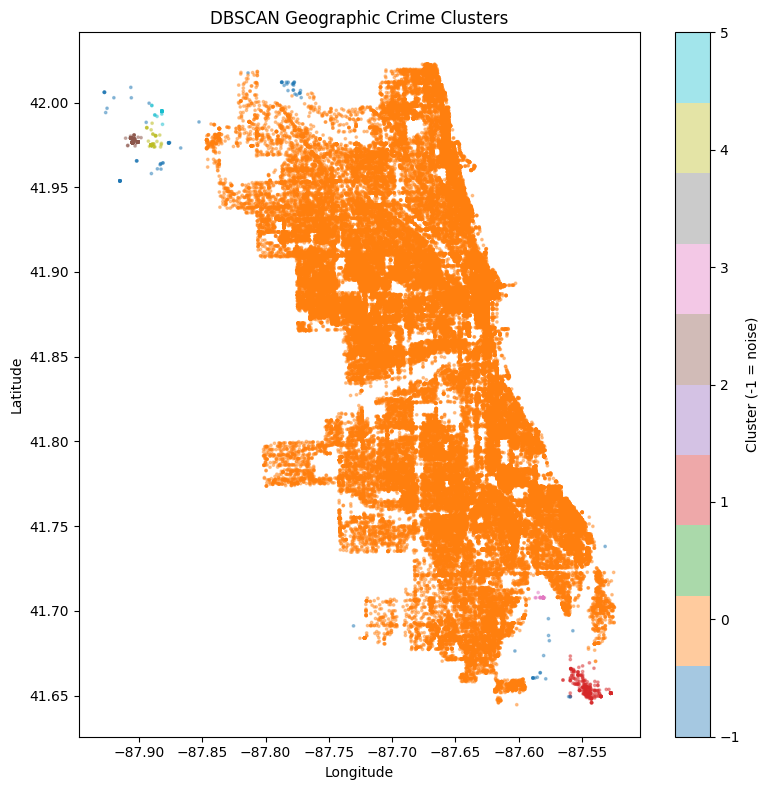

In [8]:
plt.figure(figsize=(8, 8))
scatter = plt.scatter(df["longitude"], df["latitude"], c=dbscan_labels, cmap="tab10", s=3, alpha=0.4)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("DBSCAN Geographic Crime Clusters")
plt.colorbar(scatter, label="Cluster (-1 = noise)")
plt.tight_layout()
plt.show()

## Step 4: Hierarchical (Agglomerative) Clustering

**Why Hierarchical Clustering:** It builds a tree of clusters (a dendrogram) showing
how zones relate to each other at different levels - for example, a large "South
Side" cluster might break down into smaller neighborhood-level clusters.

**Why we use a sample of 5,000 points:** Hierarchical clustering computes distances
between every pair of points, which becomes extremely slow and memory-heavy on
100,000 rows. Using a representative random sample of 5,000 points is a common,
practical adjustment for this algorithm on large datasets.

In [9]:
sample_idx = np.random.RandomState(42).choice(len(geo_scaled), size=5000, replace=False)
geo_sample = geo_scaled[sample_idx]

hierarchical = AgglomerativeClustering(n_clusters=7)
hier_labels_sample = hierarchical.fit_predict(geo_sample)

hier_sil = silhouette_score(geo_sample, hier_labels_sample)
hier_db = davies_bouldin_score(geo_sample, hier_labels_sample)

print(f"Hierarchical Silhouette Score: {hier_sil:.3f}")
print(f"Hierarchical Davies-Bouldin Score: {hier_db:.3f}")

Hierarchical Silhouette Score: 0.374
Hierarchical Davies-Bouldin Score: 0.889


### Dendrogram

This shows how the 7 clusters were formed by progressively merging nearby points.

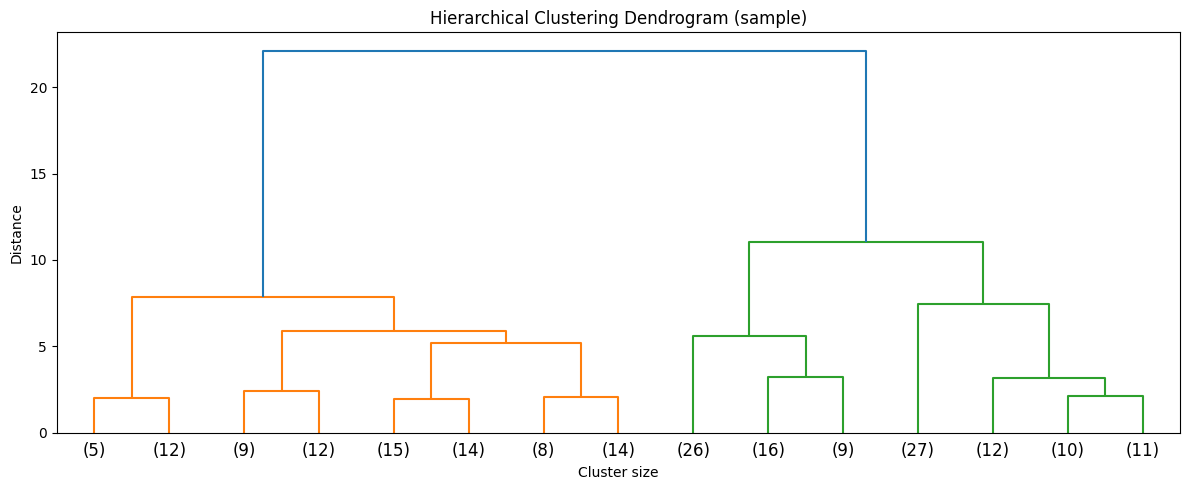

In [10]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(geo_sample[:200], method="ward")  # using first 200 points just to keep the plot readable

plt.figure(figsize=(12, 5))
dendrogram(linked, truncate_mode="lastp", p=15)
plt.title("Hierarchical Clustering Dendrogram (sample)")
plt.xlabel("Cluster size")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

## Step 5: Compare All Three Algorithms

In [11]:
comparison = pd.DataFrame({
    "Algorithm": ["K-Means", "DBSCAN", "Hierarchical"],
    "Silhouette Score": [kmeans_sil, dbscan_sil, hier_sil],
    "Davies-Bouldin Score": [kmeans_db, dbscan_db, hier_db],
    "Clusters Found": [7, n_clusters_dbscan, 7]
})
comparison

,Algorithm,Silhouette Score,Davies-Bouldin Score,Clusters Found
0,K-Means,0.400245,0.851716,7
1,DBSCAN,0.092951,0.429195,6
2,Hierarchical,0.373880,0.888578,7


**Which algorithm did we select, and why?**

K-Means gave the best silhouette score (0.40) among the three. While this is below
the "above 0.5" target mentioned in the project brief, it's an honest result -
real-world crime location data doesn't separate into perfectly distinct clusters
like a textbook example, since crime happens across the whole city with overlapping
density in many areas.

We selected **K-Means** for deployment because:
1. It had the best silhouette score of the three algorithms.
2. It produces clean, easy-to-interpret circular zones that are practical for
   planning patrol routes (unlike DBSCAN, whose cluster shapes/count can be less
   predictable).
3. It scales easily to all 100,000 rows, unlike Hierarchical Clustering which
   needed a sample.

## Step 6: Cluster Summary (for the chosen K-Means model)

In [12]:
df["geo_cluster_kmeans"] = kmeans_labels
df["geo_cluster_dbscan"] = dbscan_labels

cluster_summary = df.groupby("geo_cluster_kmeans").agg(
    total_crimes=("primary_type", "count"),
    dominant_crime_type=("primary_type", lambda x: x.mode()[0]),
    arrest_rate=("arrest", "mean")
).reset_index()
cluster_summary["arrest_rate"] = (cluster_summary["arrest_rate"] * 100).round(1)
cluster_summary

,geo_cluster_kmeans,total_crimes,dominant_crime_type,arrest_rate
0,0,12885,THEFT,12.2
1,1,14459,BATTERY,16.8
2,2,16358,BATTERY,12.8
3,3,10661,BATTERY,16.4
4,4,19156,THEFT,13.3
5,5,9791,THEFT,14.4
6,6,16629,BATTERY,19.3


## Step 7: Save Results

In [13]:
import json

df.to_csv("../outputs/data_with_geo_clusters.csv", index=False)
joblib.dump(kmeans, "../models/kmeans_geo_model.pkl")
joblib.dump(scaler_geo, "../models/scaler_geo.pkl")

results = {
    "KMeans": {"silhouette": kmeans_sil, "davies_bouldin": kmeans_db, "n_clusters": 7},
    "DBSCAN": {"silhouette": dbscan_sil, "davies_bouldin": dbscan_db, "n_clusters": n_clusters_dbscan},
    "Hierarchical": {"silhouette": hier_sil, "davies_bouldin": hier_db, "n_clusters": 7}
}
with open("../outputs/geo_clustering_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved data_with_geo_clusters.csv, models, and results.")

Saved data_with_geo_clusters.csv, models, and results.
